<a href="https://colab.research.google.com/github/Rk-D-prince/Resume_Builder/blob/master/Assignment_eCommerce_Transactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

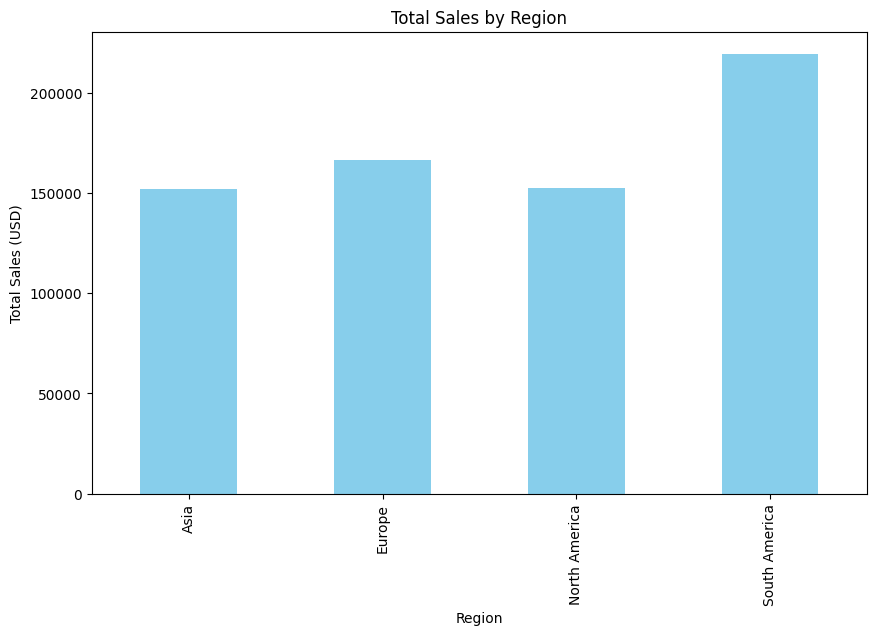

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
customers_df = pd.read_csv("Customers.csv")
products_df = pd.read_csv("Products.csv")
transactions_df = pd.read_csv("Transactions.csv")

# Task 1: EDA
# Convert date columns to datetime
customers_df['SignupDate'] = pd.to_datetime(customers_df['SignupDate'])
transactions_df['TransactionDate'] = pd.to_datetime(transactions_df['TransactionDate'])

# Merge datasets
transactions_merged = transactions_df.merge(customers_df, on="CustomerID", how="left").merge(products_df, on="ProductID", how="left")

# Top customers by revenue
top_customers = transactions_merged.groupby("CustomerName")["TotalValue"].sum().sort_values(ascending=False)

# Top product categories by revenue
top_categories = transactions_merged.groupby("Category")["TotalValue"].sum().sort_values(ascending=False)

# Regional sales distribution
region_sales = transactions_merged.groupby("Region")["TotalValue"].sum()

# Visualization: Regional sales
plt.figure(figsize=(10, 6))
region_sales.plot(kind='bar', color='skyblue', title="Total Sales by Region")
plt.ylabel("Total Sales (USD)")
plt.show()



In [2]:
# Task 2: Lookalike Model
# Feature engineering for lookalike model
customer_features = transactions_merged.groupby('CustomerID').agg({
    'TotalValue': 'sum',
    'Quantity': 'sum',
    'Price_x': 'mean'
}).rename(columns={
    'TotalValue': 'TotalSpent',
    'Quantity': 'TotalQuantity',
    'Price_x': 'AvgPrice'
}).reset_index()

# Add region as one-hot encoded features
region_dummies = pd.get_dummies(customers_df[['CustomerID', 'Region']], columns=['Region'])
customer_features = customer_features.merge(region_dummies, on='CustomerID', how='left')

# Normalize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(customer_features.iloc[:, 1:])

# Compute cosine similarity
similarity_matrix = cosine_similarity(features_scaled)
similarity_df = pd.DataFrame(similarity_matrix, index=customer_features['CustomerID'], columns=customer_features['CustomerID'])

# Get top 3 lookalikes for each customer
lookalike_results = {}
for customer in similarity_df.index[:20]:  # First 20 customers (C0001 - C0020)
    similar_customers = similarity_df.loc[customer].sort_values(ascending=False).iloc[1:4]
    lookalike_results[customer] = list(zip(similar_customers.index, similar_customers.values))

# Save lookalike results
lookalike_data = []
for customer, similars in lookalike_results.items():
    for similar_customer, score in similars:
        lookalike_data.append([customer, similar_customer, score])
lookalike_df = pd.DataFrame(lookalike_data, columns=['CustomerID', 'SimilarCustomerID', 'SimilarityScore'])
lookalike_df.to_csv("Lookalike.csv", index=False)



**Customer Insights**

Top Spenders: Analyze the top customers by revenue (in top_customers) to
understand their buying behavior and preferences. This can help tailor marketing campaigns or loyalty programs to high-value customers.

**Product Insights**

Best-Selling Categories: Identify the top product categories by revenue (in top_categories) to focus marketing efforts and inventory management on these high-performing categories.

**Sales Insights**

Regional Performance: Visualize regional sales distribution (in region_sales and the corresponding plot) to identify strong and weak regions. This can inform targeted regional marketing strategies or store placement decisions.

Customer Acquisition: Analyze customer signup dates (in customers_df['SignupDate']) to understand customer acquisition trends over time. This can help identify optimal periods for marketing campaigns.

Purchase Frequency: Explore transaction frequency within the transactions_df to understand how often customers typically purchase. This can inform decisions about promotional frequency or subscription models.

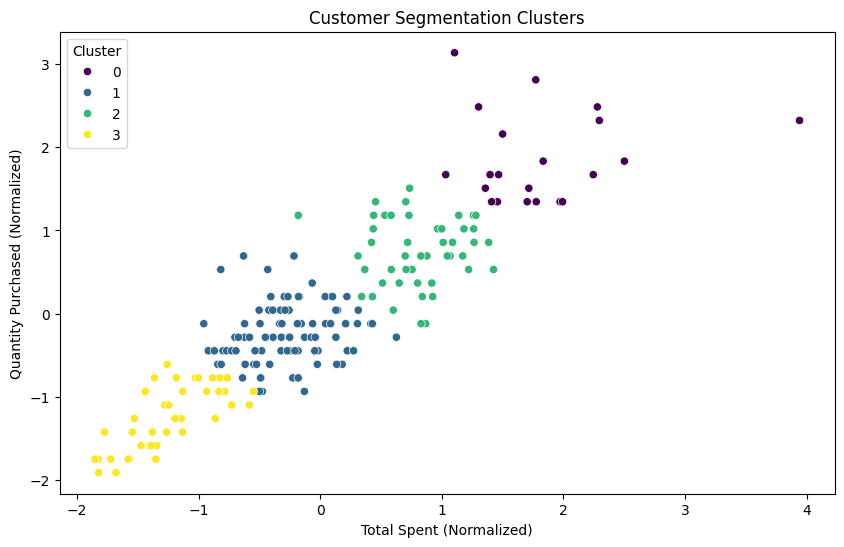

Davies-Bouldin Index: 0.72127971818163


In [3]:
# Task 3: Customer Segmentation / Clustering
# Prepare clustering data
clustering_data = transactions_merged.groupby('CustomerID').agg({
    'TotalValue': 'sum',
    'Quantity': 'sum'
}).reset_index()

# Normalize clustering data
clustering_scaled = scaler.fit_transform(clustering_data[['TotalValue', 'Quantity']])

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
clustering_data['Cluster'] = kmeans.fit_predict(clustering_scaled)

# Calculate DB Index
db_index = davies_bouldin_score(clustering_scaled, clustering_data['Cluster'])

# Visualize Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=clustering_scaled[:, 0],
    y=clustering_scaled[:, 1],
    hue=clustering_data['Cluster'],
    palette='viridis'
)
plt.title("Customer Segmentation Clusters")
plt.xlabel("Total Spent (Normalized)")
plt.ylabel("Quantity Purchased (Normalized)")
plt.show()

# Save clustering results
clustering_data.to_csv("Clustering_Results.csv", index=False)

# Output DB Index
print(f"Davies-Bouldin Index: {db_index}")